In [7]:
import sys
sys.path.insert(0, "/home/winnieyangwn/rllm")
import importlib

import analysis.utils.eval_utils as eval_utils 

importlib.reload(eval_utils)
from analysis.utils.eval_utils import *

/storage/home/winnieyangwn/miniforge3/envs/aira-dojo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
data_path = "/checkpoint/maui_sft/winnieyangwn/rllm/eval/replicate_code_v3s/results/trajectories.jsonl"

In [9]:
import pandas as pd

df = pd.read_json(data_path, lines=True)

Found 6 rollouts matching valid criteria
Found 18 rollouts matching invalid criteria (excluding infra errors)
Found 36 rollouts with infrastructure errors

Infrastructure Error Breakdown:
   Infrastructure Error Category  Count  Percentage
Infrastructure: Model Call Error     36       100.0


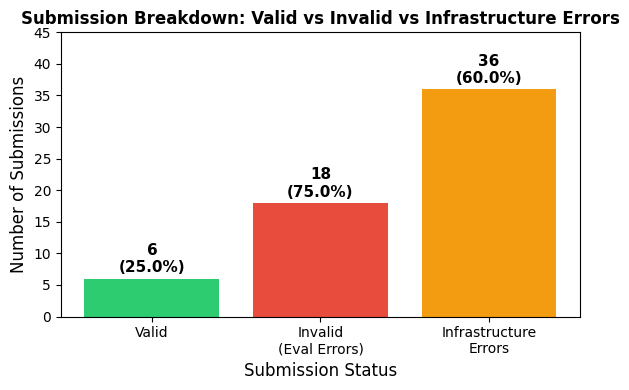

In [10]:
valid_df, invalid_df, infra_df = plot_submission_validity_breakdown(df)

Analyzing 60 rows for invalid submissions...
Found 54 invalid submissions

ERROR CATEGORY DISTRIBUTION


,Count,Percentage
Error Category,,
Infrastructure: Model Call Error,36,66.67
Empty error message,18,33.33



Total: 54

ROLLOUT INDICES BY ERROR CATEGORY


,Error Category,Count,Rollout Indices
0,Infrastructure: Model Call Error,36,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
1,Empty error message,18,"[36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 4..."


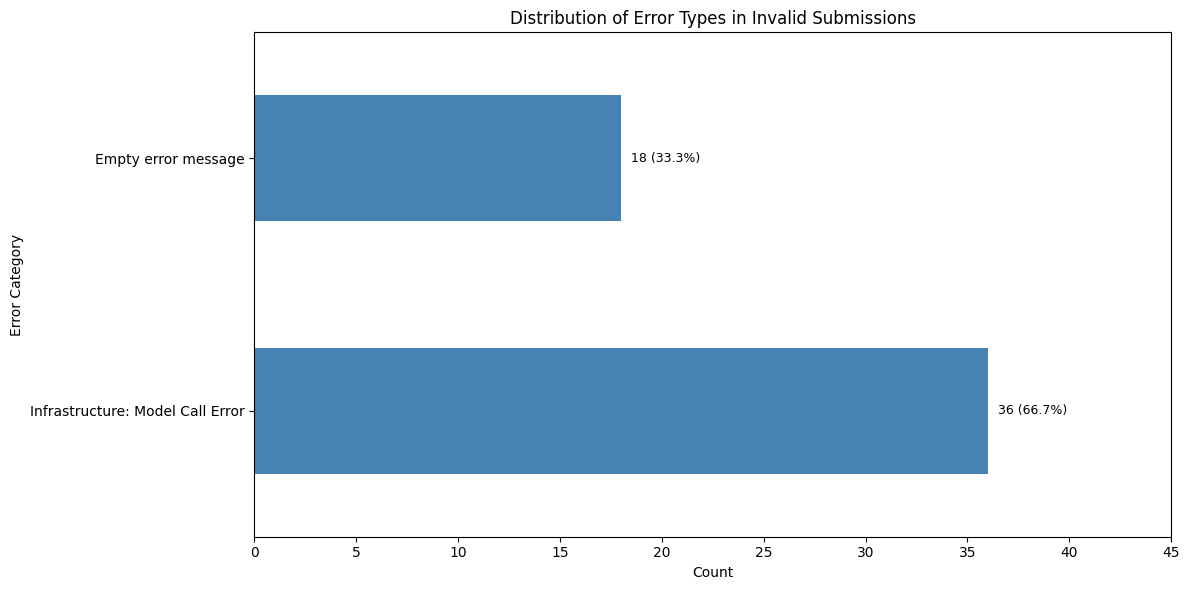


ERROR CATEGORY PERCENTAGE
Infrastructure: Model Call Error: 66.67%
Empty error message: 33.33%


In [11]:
# First analyze invalid submissions
df_errors, summary_df, rollout_indices_df = analyze_invalid_submissions(df)

# Then plot the distribution
error_counts, error_pct = plot_invalid_error_distribution(df_errors)

In [12]:
df.iloc[0]["outcomes"]

{'pass': False,
 'valid_submission': False,
 'pred_solution_provided': False,
 'submission_csv_provided': False,
 'max_turns_reached': False,
 'rollout_timeout': False,
 'context_exceeded': False,
 'model_call_error': True,
 'parse_error': False,
 'eval_timeout': False,
 'eval_outcome': 'fail',
 'eval_error_message': '',
 'eval_error_output': ''}

In [13]:
# Test process_df function
importlib.reload(eval_utils)
from analysis.utils.eval_utils import process_df

df_processed, df_task = process_df(df, Ks=[1, 4, 8, 16, 24, 32, 40, 48, 56, 64])

print("=== df_processed (rollout-level) ===")
print(f"Shape: {df_processed.shape}")


print("\n\n=== df_task (task-level) ===")
print(f"Shape: {df_task.shape}")
display(df_task)

=== df_processed (rollout-level) ===
Shape: (60, 17)


=== df_task (task-level) ===
Shape: (1, 28)


,n_rollouts,pass@1,pass@4,pass@8,pass@16,pass@24,pass@32,pass@40,pass@48,pass@56,...,valid_pass@48,valid_pass@56,valid_pass@64,any_medal_rate,gold_medal_rate,silver_medal_rate,bronze_medal_rate,gold_threshold,silver_threshold,bronze_threshold
task_name,,,,,,,,,,,,,,,,,,,,,
mlsp-2013-birds,60,0.028704,0.10495,0.186467,0.296198,0.356884,0.387731,0.401526,0.406416,0.407391,...,0.999982,1.0,NaN,0.0,0.0,0.0,0.0,0.907407,0.808642,0.611111


In [14]:
get_summary_stats(df)

{'total': 60,
 'valid_submissions': 6,
 'valid_rate': np.float64(10.0),
 'passed': 6,
 'pass_rate': np.float64(10.0),
 'avg_percentile': np.float64(0.02870370370370365),
 'min_percentile': np.float64(0.0),
 'max_percentile': np.float64(0.40740740740740705),
 'avg_score': np.float64(0.7362150000000001)}

In [15]:
df.shape

(60, 9)

Using pre-computed pass@k for 1 tasks
Tasks: ['mlsp-2013-birds']


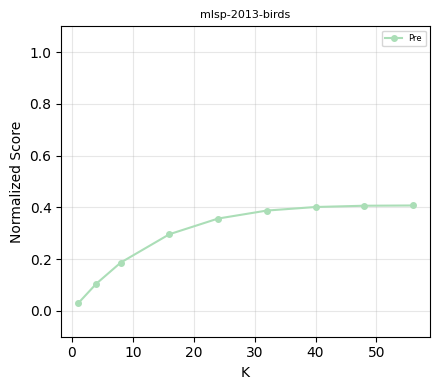

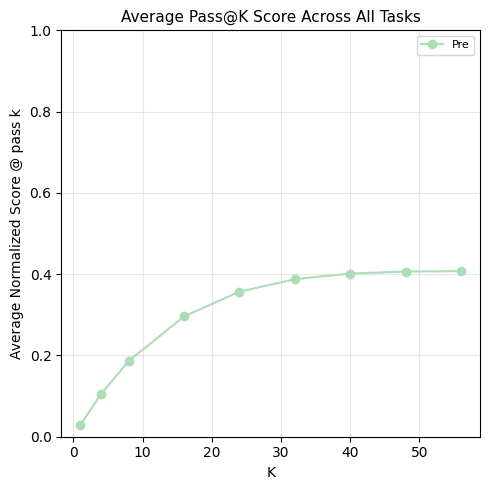

K	Pre
1	0.0287
4	0.1050
8	0.1865
16	0.2962
24	0.3569
32	0.3877
40	0.4015
48	0.4064
56	0.4074
64	nan


In [16]:
# Test pass@k for percentile scores
results_df = plot_pass_at_k(df_task, metric="percentile")

In [17]:
# Compare metrics across the full dataset
plot_metric_comparison([df_processed], labels=["All"], metric="percentile", agg="mean")


plot_metric_comparison([df_processed], labels=["All"], metric="medal", agg="mean")


Mean Percentile All: 0.0287 ± 0.0970


Mean Any Medal All: 0.0000 ± 0.0000
Mean Gold Medal All: 0.0000 ± 0.0000
Mean Silver Medal All: 0.0000 ± 0.0000
Mean Bronze Medal All: 0.0000 ± 0.0000


({'any_medal': {'values': [np.float64(0.0)], 'stds': [np.float64(0.0)]},
  'gold_medal': {'values': [np.float64(0.0)], 'stds': [np.float64(0.0)]},
  'silver_medal': {'values': [np.float64(0.0)], 'stds': [np.float64(0.0)]},
  'bronze_medal': {'values': [np.float64(0.0)], 'stds': [np.float64(0.0)]}},
 None)